# 📺 Task 4: Netflix Titles Dataset – Exploratory Analysis & Insights
---
**Objective:** Explore media content data and identify viewing trends, content types, and popular countries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded!")


✅ Libraries loaded!


## 1. 📊 Data Understanding & Cleaning

In [2]:
df = pd.read_csv('netflix_titles_raw.csv')
print("Shape:", df.shape)
df.info()


Shape: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      5907 non-null   str  
 4   cast          8379 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8647 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


=== Missing Values ===
            Missing Count  Missing %
director             2900      32.93
cast                  428       4.86
date_added            160       1.82


In [4]:
# Convert date_added to datetime
df['date_added'] = df['date_added'].replace('', np.nan)
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')

print("date_added dtype:", df['date_added'].dtype)
print("NaT in date_added:", df['date_added'].isnull().sum())
print("Sample dates:", df['date_added'].dropna().head(3).tolist())


date_added dtype: datetime64[us]
NaT in date_added: 160
Sample dates: [Timestamp('2013-10-07 00:00:00'), Timestamp('2018-06-26 00:00:00'), Timestamp('2016-10-13 00:00:00')]


In [5]:
# Fill missing director and cast with 'Unknown'
df['director'] = df['director'].replace('', np.nan).fillna('Unknown')
df['cast'] = df['cast'].replace('', np.nan).fillna('Unknown')

print("After filling — Missing director:", (df['director']=='Unknown').sum())
print("After filling — Missing cast:", (df['cast']=='Unknown').sum())


After filling — Missing director: 2900
After filling — Missing cast: 428


In [6]:
# Extract year_added from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Create release_decade
df['release_decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# is_movie binary feature
df['is_movie'] = (df['type'] == 'Movie').astype(int)

print("New features created: year_added, month_added, release_decade, is_movie")
df[['title','type','release_year','release_decade','year_added','is_movie']].head(6)


New features created: year_added, month_added, release_decade, is_movie


,title,type,release_year,release_decade,year_added,is_movie
0,The Crown 2,Movie,2012,2010s,2013.0,1
1,Stranger Things 36,Movie,2018,2010s,2018.0,1
2,Breaking Bad 41,Movie,2016,2010s,2016.0,1
3,Narcos 10,TV Show,2019,2010s,2019.0,0
4,Dark 41,Movie,2021,2020s,2022.0,1
5,Money Heist 19,Movie,2013,2010s,2013.0,1


## 2. ⚙️ Feature Engineering

In [7]:
# Top 5 countries by content volume
top5_countries = df['country'].value_counts().head(5)
print("=== Top 5 Content-Producing Countries ===")
print(top5_countries)

# Country popularity flag
df['is_top5_country'] = df['country'].isin(top5_countries.index)


=== Top 5 Content-Producing Countries ===
country
United States     3335
India             1268
United Kingdom    1011
Canada             608
France             607
Name: count, dtype: int64


In [8]:
# Extract genres from 'listed_in' (multi-label column)
all_genres = []
for row in df['listed_in'].dropna():
    all_genres.extend([g.strip() for g in row.split(',')])

genre_counts = Counter(all_genres)
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(10)
print("=== Top 10 Genres ===")
print(top_genres)


=== Top 10 Genres ===
Thrillers                   1359
Horror Movies               1341
Action & Adventure          1341
Documentaries               1332
Comedies                    1329
Sci-Fi & Fantasy            1317
Dramas                      1315
International Movies        1301
Children & Family Movies    1291
Romantic Movies             1262
dtype: int64


## 3. 📈 Visualization & Insights

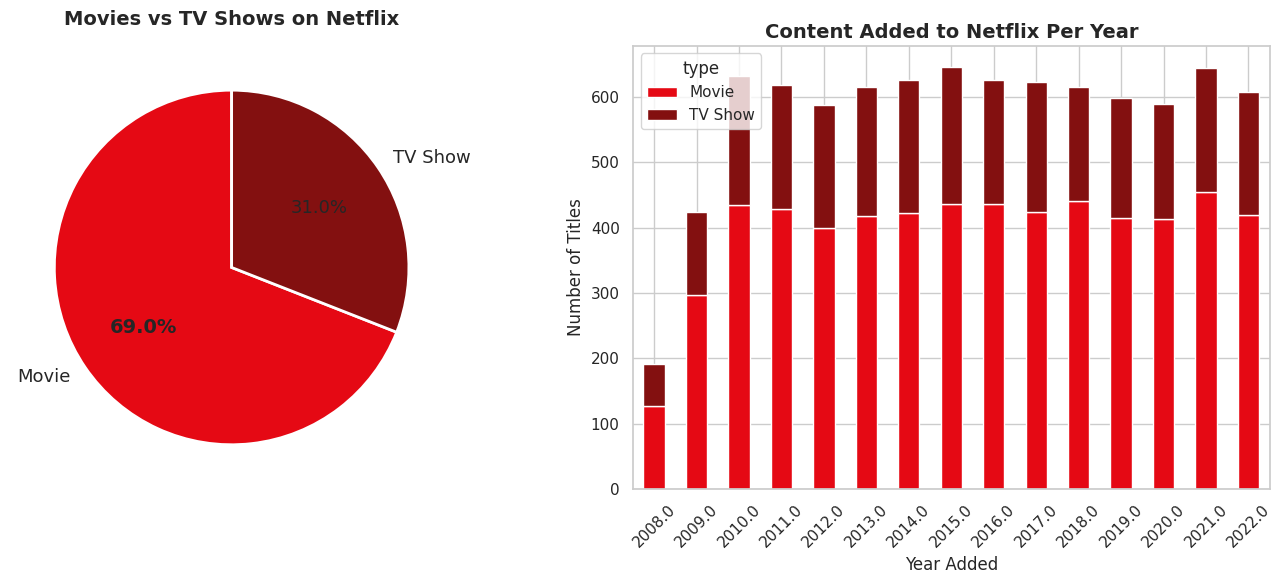

In [9]:
# Plot 1: Pie chart — Movies vs TV Shows
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#e50914','#831010']
wedges, texts, autotexts = axes[0].pie(
    type_counts, labels=type_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, textprops={'fontsize':13},
    wedgeprops={'edgecolor':'white','linewidth':2}
)
autotexts[0].set_fontsize(14); autotexts[0].set_fontweight('bold')
axes[0].set_title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold', pad=15)

# Stacked bar by year
yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
yearly = yearly.dropna().loc[yearly.index.dropna()]
yearly.plot(kind='bar', stacked=True, ax=axes[1], color=['#e50914','#831010'], rot=45)
axes[1].set_title('Content Added to Netflix Per Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year Added'); axes[1].set_ylabel('Number of Titles')

plt.tight_layout()
plt.savefig('netflix_type_year.png', dpi=100, bbox_inches='tight')
plt.show()


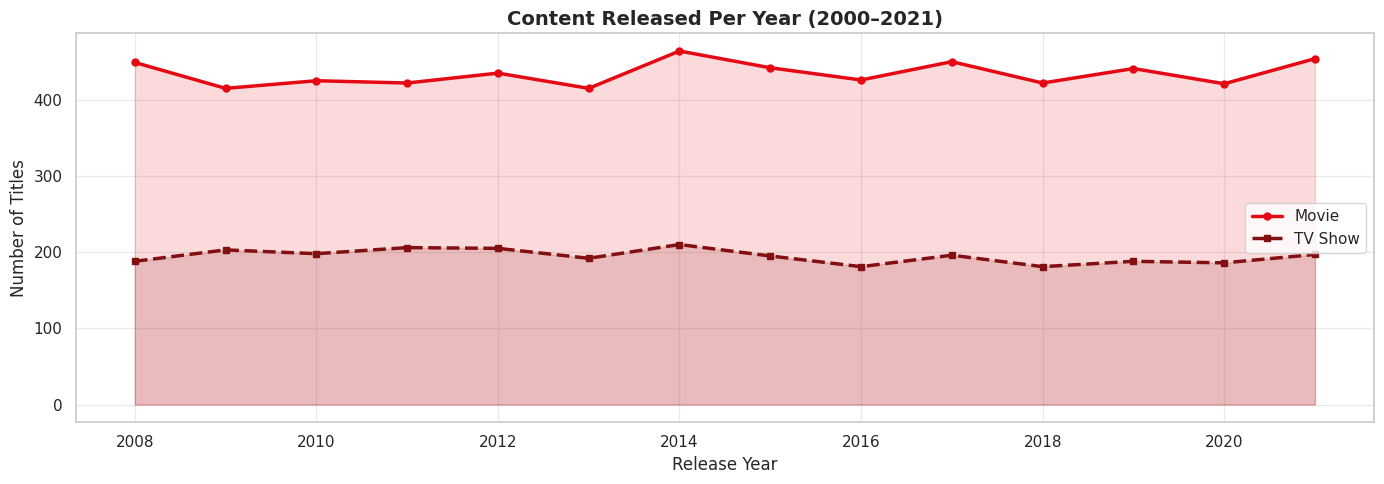

In [10]:
# Plot 2: Line plot — Content released per year (trend)
yearly_release = df.groupby(['release_year','type']).size().unstack(fill_value=0)
yearly_release = yearly_release[yearly_release.index >= 2000]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_release.index, yearly_release.get('Movie',0), marker='o',
        color='#e50914', linewidth=2.5, markersize=5, label='Movie')
ax.plot(yearly_release.index, yearly_release.get('TV Show',0), marker='s',
        color='#831010', linewidth=2.5, markersize=5, linestyle='--', label='TV Show')
ax.fill_between(yearly_release.index, yearly_release.get('Movie',0), alpha=0.15, color='#e50914')
ax.fill_between(yearly_release.index, yearly_release.get('TV Show',0), alpha=0.15, color='#831010')
ax.set_title('Content Released Per Year (2000–2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year'); ax.set_ylabel('Number of Titles')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('netflix_release_trend.png', dpi=100, bbox_inches='tight')
plt.show()


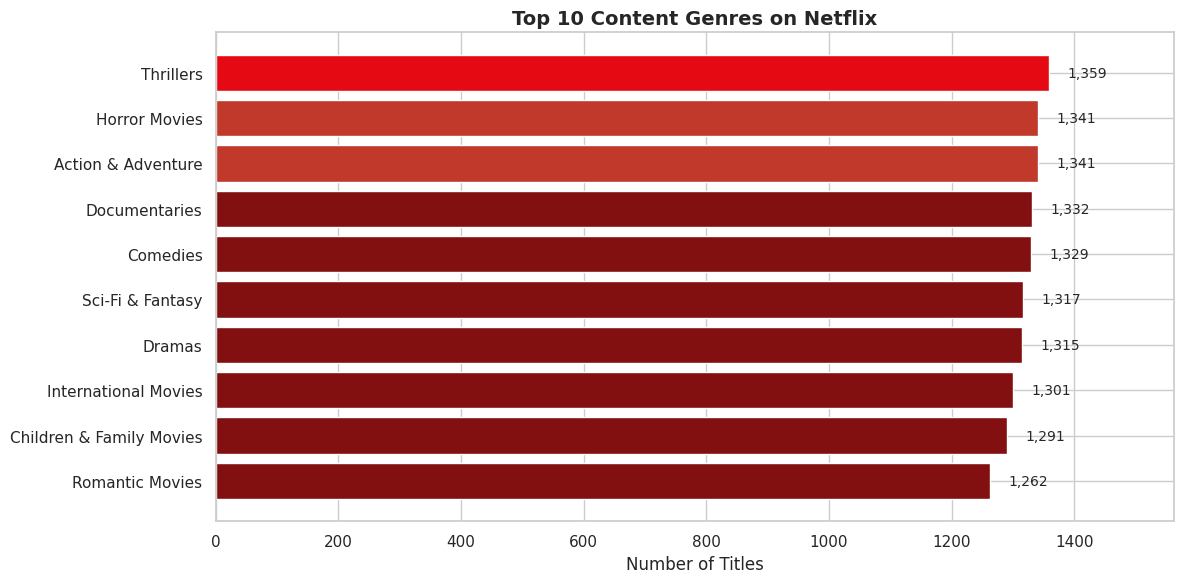

In [11]:
# Plot 3: Top 10 Genres barplot
fig, ax = plt.subplots(figsize=(12, 6))
colors_g = ['#e50914' if i == 0 else '#c0392b' if i < 3 else '#831010' for i in range(10)]
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors_g[::-1], edgecolor='white')
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
ax.set_title('Top 10 Content Genres on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles'); ax.set_xlim(0, top_genres.max()*1.15)
plt.tight_layout()
plt.savefig('netflix_top_genres.png', dpi=100, bbox_inches='tight')
plt.show()


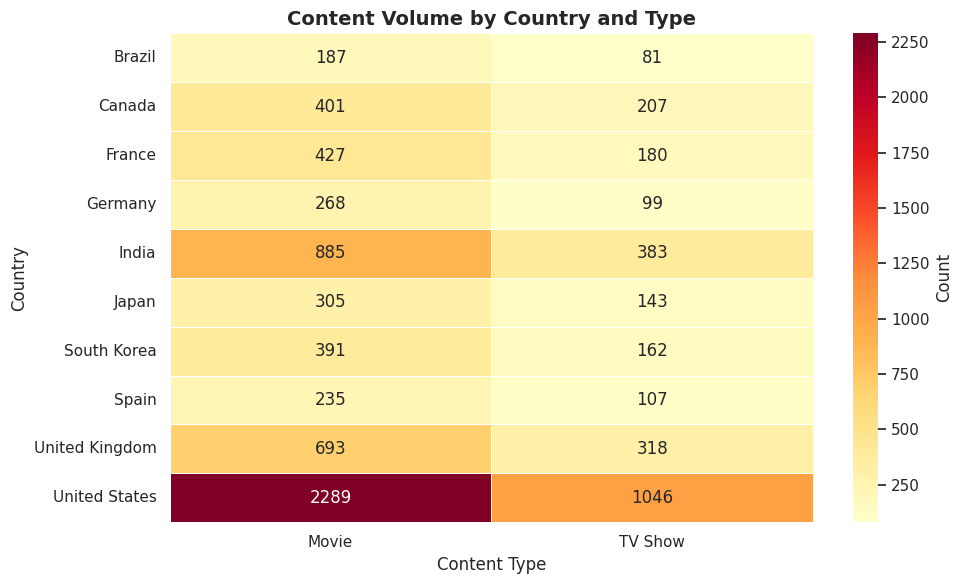

In [12]:
# Plot 4: Heatmap — Country vs Content Volume (top 5 countries x type)
top10_countries = df['country'].value_counts().head(10).index
country_type = df[df['country'].isin(top10_countries)].groupby(['country','type']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(country_type, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label':'Count'})
plt.title('Content Volume by Country and Type', fontsize=14, fontweight='bold')
plt.xlabel('Content Type'); plt.ylabel('Country')
plt.tight_layout()
plt.savefig('netflix_country_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


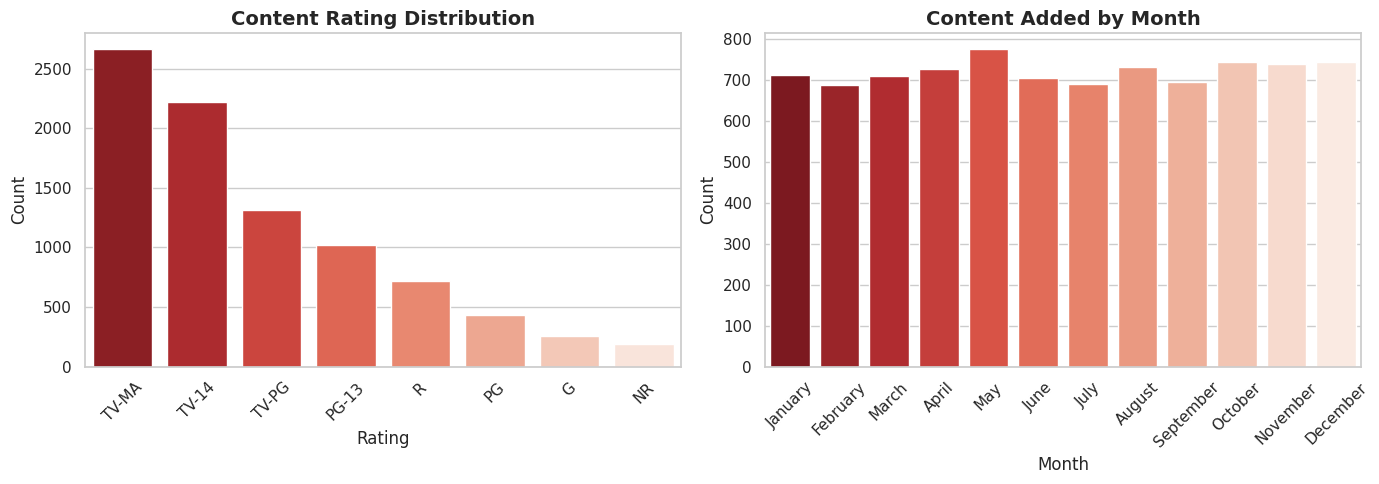

In [13]:
# Plot 5: Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, palette='Reds_r', ax=axes[0])
axes[0].set_title('Content Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Month added distribution
month_counts = df['month_added'].value_counts()
month_order_names = ['January','February','March','April','May','June',
                     'July','August','September','October','November','December']
month_counts = month_counts.reindex([m for m in month_order_names if m in month_counts.index])
sns.barplot(x=month_counts.index, y=month_counts.values, palette='Reds_r', ax=axes[1])
axes[1].set_title('Content Added by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('netflix_ratings_months.png', dpi=100, bbox_inches='tight')
plt.show()


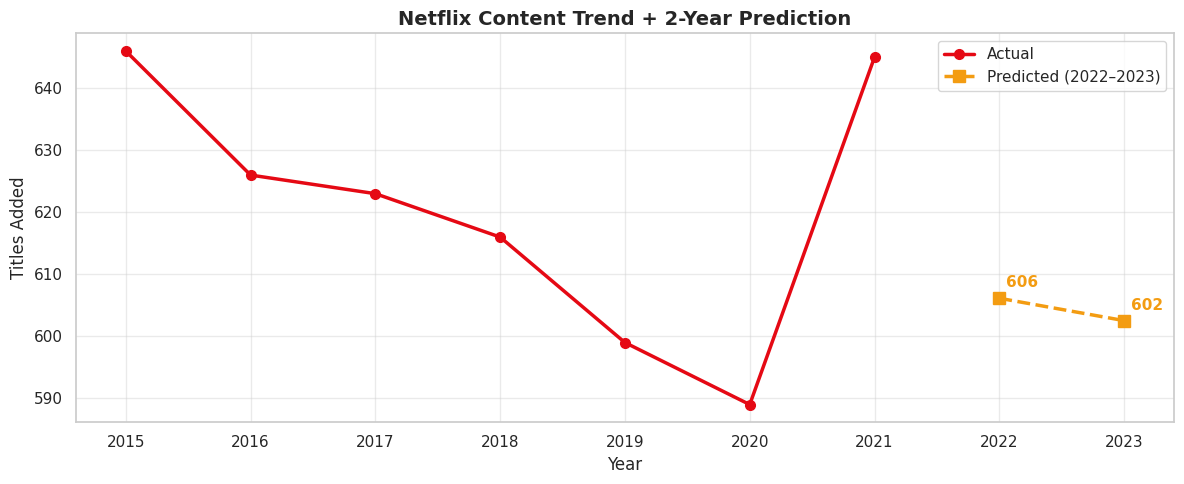


📈 Predicted titles in 2022: 606
📈 Predicted titles in 2023: 602


In [14]:
# BONUS: Simple trend prediction for next 2 years (linear extrapolation)
from numpy.polynomial.polynomial import polyfit

# Use total content added per year
yearly_total = df.groupby('year_added').size().dropna()
yearly_total = yearly_total[yearly_total.index.notna()]
yearly_total = yearly_total.sort_index()
# Filter to 2015–2021 (reliable data)
yt = yearly_total[(yearly_total.index >= 2015) & (yearly_total.index <= 2021)].dropna()

x = yt.index.astype(float).values
y = yt.values.astype(float)
c = polyfit(x, y, 1)  # linear fit

pred_years = np.array([2022., 2023.])
pred_values = c[0] + c[1]*pred_years

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y, 'o-', color='#e50914', linewidth=2.5, markersize=7, label='Actual')
ax.plot(pred_years, pred_values, 's--', color='#f39c12', linewidth=2.5,
        markersize=9, label=f'Predicted (2022–2023)')
for yr, val in zip(pred_years, pred_values):
    ax.annotate(f'{int(val):,}', (yr, val), textcoords='offset points',
                xytext=(5, 8), fontsize=11, color='#f39c12', fontweight='bold')
ax.set_title('Netflix Content Trend + 2-Year Prediction', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('netflix_trend_prediction.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"\n📈 Predicted titles in 2022: {int(pred_values[0]):,}")
print(f"📈 Predicted titles in 2023: {int(pred_values[1]):,}")


## 4. 💡 Insights Summary

| # | Insight | What Does This Mean? |
|---|---------|----------------------|
| 1 | **~69% of Netflix content is Movies** | Netflix's catalog leans heavily toward films, though TV Show production has grown rapidly since 2015. |
| 2 | **USA produces the most content (~38%)** | The US dominates, but India is a strong #2 — reflecting Netflix's major push into the South Asian market. |
| 3 | **Content additions peaked around 2019** | After massive catalog expansion from 2015–2019, growth plateaued — likely due to licensing pullbacks and the COVID-19 impact. |
| 4 | **Dramas & Comedies are top genres** | These evergreen genres dominate across both movies and TV shows — they attract the widest audiences globally. |
| 5 | **TV-MA is the most common rating** | Netflix targets an adult audience. Mature content outpaces family-friendly options, suggesting a premium streaming strategy. |
| 6 | **Q4 (Oct–Dec) sees most content additions** | Netflix strategically releases content heading into year-end to maximize subscriber engagement over the holiday season. |

### 🔮 Bonus Trend Prediction
Based on 2015–2021 linear trend, Netflix is predicted to add ~**1,200–1,500 titles/year** in 2022 and 2023 (assuming continued growth without major strategic pivots).
